<a href="https://colab.research.google.com/github/renzotaco/Python/blob/main/FACEMP_ML2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data loading

### Subtask:
Load the data from the "FACEMP.xlsx" file.


**Reasoning**:
Load the data from the excel file into a pandas DataFrame and display the first few rows and the shape of the DataFrame.



In [1]:
import pandas as pd

try:
    df = pd.read_excel('FACEMP.xlsx', sheet_name='Hoja4')
    display(df.head())
    print(df.shape)
except FileNotFoundError:
    print("Error: 'FACEMP.xlsx' not found.")
except Exception as e:
    print(f"An error occurred: {e}")

An error occurred: Worksheet named 'Hoja4' not found


**Reasoning**:
The previous attempt failed because the sheet name was incorrect.  I will try to load the data again, this time iterating through all sheet names to identify the correct one and load it into a pandas DataFrame.  The sheet name might have been mistyped in the user's instructions. Then, I will display the first few rows of the DataFrame.



In [2]:
import pandas as pd

try:
    xl = pd.ExcelFile('FACEMP.xlsx')
    for sheet_name in xl.sheet_names:
        print(f"Trying sheet: {sheet_name}")
        try:
            df = pd.read_excel('FACEMP.xlsx', sheet_name=sheet_name)
            display(df.head())
            print(df.shape)
            break # Exit the loop once a sheet is successfully loaded
        except Exception as e:
            print(f"Error loading sheet '{sheet_name}': {e}")
    else: # If no sheet was loaded successfully
        print("No suitable sheet found in the Excel file.")
except FileNotFoundError:
    print("Error: 'FACEMP.xlsx' not found.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Trying sheet: FACEMP


,V1,V2,V3,V4,V5,V6,V10,V11,V12,V13,...,F5,VI,VD,VIF,F1F,F2F,F3F,F4F,F5F,VDF
0,5,5,5,5,5,5,4,5,5,5,...,30,100,30,3,3,3,3,3,3,3
1,2,2,3,3,3,3,3,3,3,3,...,30,79,30,3,2,2,3,3,3,3
2,4,5,5,4,4,3,3,3,4,4,...,24,78,24,3,3,3,2,2,3,3
3,5,5,5,5,5,5,4,5,5,4,...,24,82,24,3,3,2,2,3,3,3
4,1,5,5,5,5,5,4,4,5,1,...,30,92,30,3,3,3,3,3,3,3


(154, 40)


## Data exploration

### Subtask:
Explore the loaded data (df) to understand its characteristics.


**Reasoning**:
Examine data types, missing values, distributions, descriptive statistics, and relationships between variables, especially focusing on 'F1'-'F5' and 'VD'.



V1     int64
V2     int64
V3     int64
V4     int64
V5     int64
V6     int64
V10    int64
V11    int64
V12    int64
V13    int64
V14    int64
V15    int64
V16    int64
V17    int64
V18    int64
V19    int64
V20    int64
V21    int64
V22    int64
V23    int64
V24    int64
V25    int64
V26    int64
V27    int64
V28    int64
V29    int64
F1     int64
F2     int64
F3     int64
F4     int64
F5     int64
VI     int64
VD     int64
VIF    int64
F1F    int64
F2F    int64
F3F    int64
F4F    int64
F5F    int64
VDF    int64
dtype: object
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
F1     0
F2     0
F3     0
F4     0
F5     0
VI     0
VD     0
VIF    0
F1F    0
F2F    0
F3F    0
F4F    0
F5F    0
VDF    0
dtype: int64


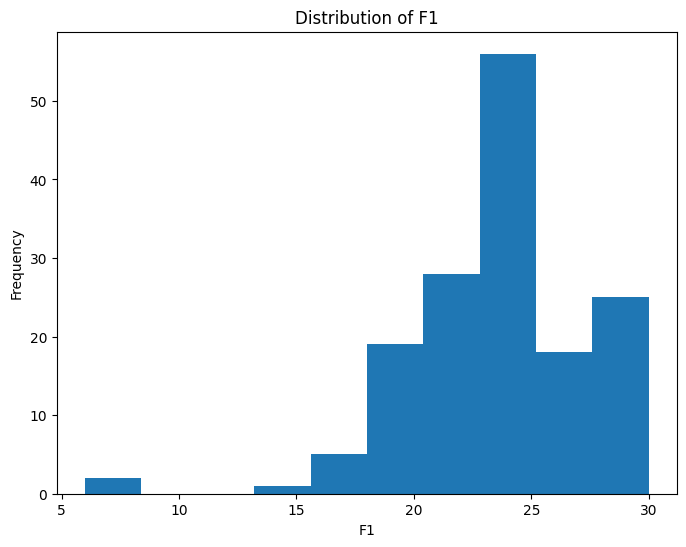

count    154.000000
mean      23.519481
std        3.939445
min        6.000000
25%       21.000000
50%       24.000000
75%       26.000000
max       30.000000
Name: F1, dtype: float64


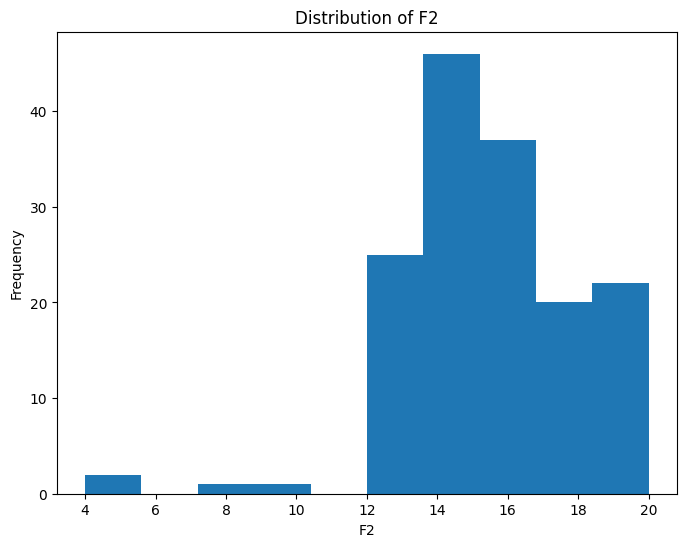

count    154.000000
mean      15.435065
std        2.641858
min        4.000000
25%       14.000000
50%       16.000000
75%       17.000000
max       20.000000
Name: F2, dtype: float64


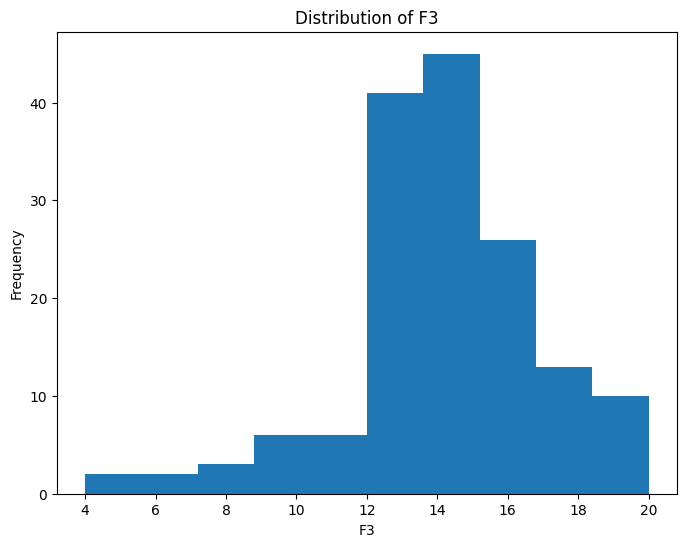

count    154.000000
mean      14.077922
std        2.877754
min        4.000000
25%       12.000000
50%       14.000000
75%       16.000000
max       20.000000
Name: F3, dtype: float64


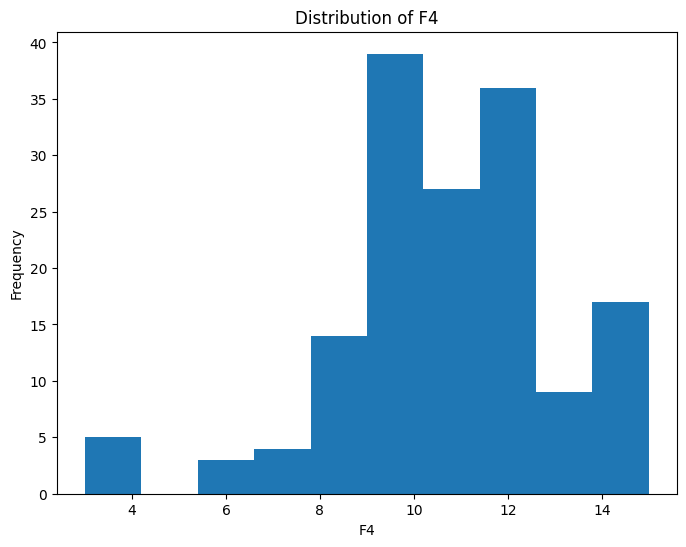

count    154.000000
mean      10.636364
std        2.499198
min        3.000000
25%        9.000000
50%       11.000000
75%       12.000000
max       15.000000
Name: F4, dtype: float64


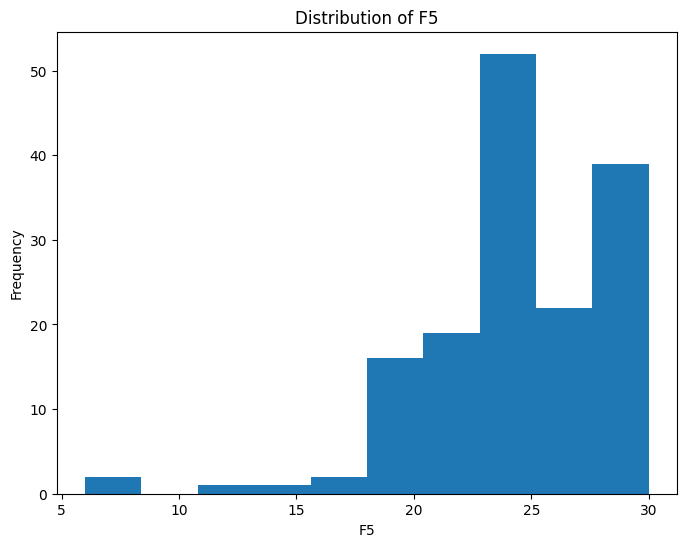

count    154.000000
mean      24.448052
std        4.200906
min        6.000000
25%       22.000000
50%       24.000000
75%       27.750000
max       30.000000
Name: F5, dtype: float64


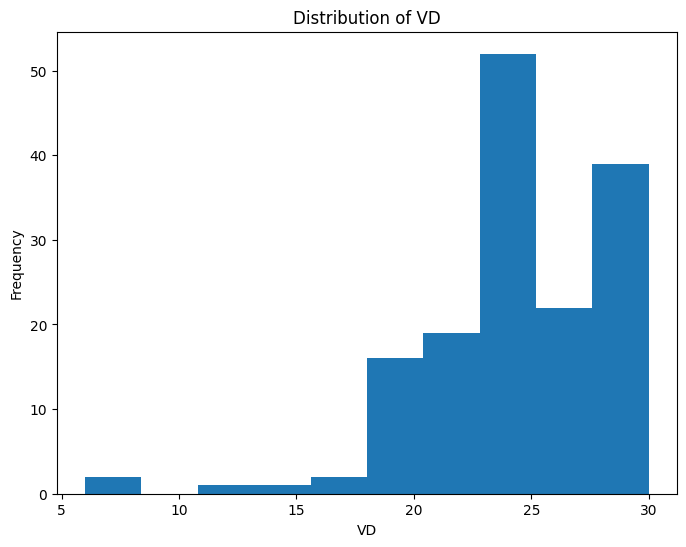

count    154.000000
mean      24.448052
std        4.200906
min        6.000000
25%       22.000000
50%       24.000000
75%       27.750000
max       30.000000
Name: VD, dtype: float64
          F1        F2        F3        F4        F5        VD
F1  1.000000  0.510691  0.504327  0.269585  0.404480  0.404480
F2  0.510691  1.000000  0.574947  0.465621  0.417533  0.417533
F3  0.504327  0.574947  1.000000  0.463803  0.413390  0.413390
F4  0.269585  0.465621  0.463803  1.000000  0.338094  0.338094
F5  0.404480  0.417533  0.413390  0.338094  1.000000  1.000000
VD  0.404480  0.417533  0.413390  0.338094  1.000000  1.000000


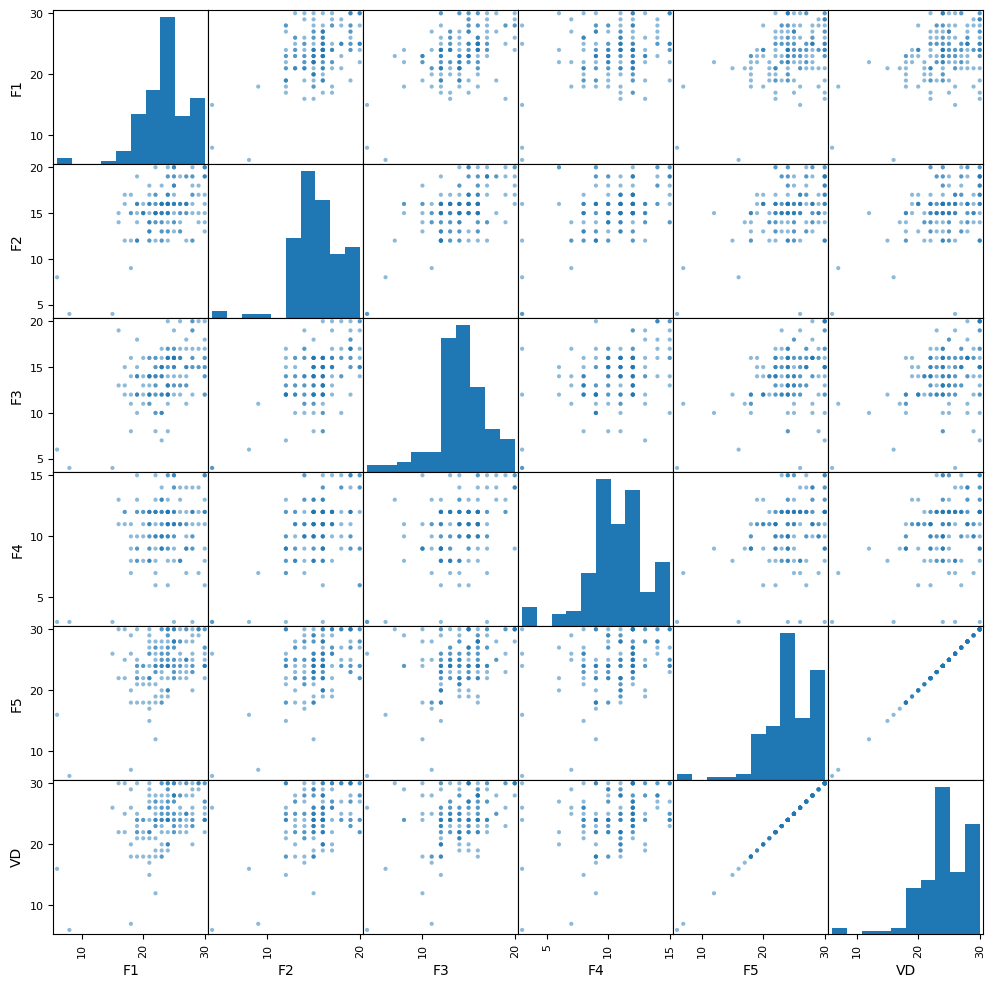

In [3]:
# Check data types
print(df.dtypes)

# Check for missing values
print(df.isnull().sum())

# Analyze distributions and descriptive statistics
import matplotlib.pyplot as plt
for col in ['F1', 'F2', 'F3', 'F4', 'F5', 'VD']:
    plt.figure(figsize=(8, 6))
    df[col].plot(kind='hist', title=f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()
    print(df[col].describe())

# Calculate correlations and create scatter plots
correlation_matrix = df[['F1', 'F2', 'F3', 'F4', 'F5', 'VD']].corr()
print(correlation_matrix)
pd.plotting.scatter_matrix(df[['F1', 'F2', 'F3', 'F4', 'F5', 'VD']], figsize=(12, 12), alpha=0.5)
plt.show()

## Data preparation

### Subtask:
Prepare the data for modeling by handling potential issues like multicollinearity and ensuring the dependent variable is suitable for classification.


**Reasoning**:
Remove the 'F5' column due to perfect correlation with 'VD', and ensure 'VD' is suitable for classification.  Check data types and handle missing values if any.



In [4]:
# Remove 'F5' due to perfect correlation with 'VD'
if 'F5' in df.columns:
    df = df.drop('F5', axis=1)

# Check unique values of 'VD'
print(df['VD'].unique())

# Convert 'VD' to categorical if necessary (e.g., if it's continuous)
# Based on the unique values, decide if conversion is needed
# Example (replace with actual logic):
# if len(df['VD'].unique()) <= 10: # Example condition for converting to categorical
#     df['VD'] = df['VD'].astype('category')


# Verify data types of independent variables
for col in ['F1', 'F2', 'F3', 'F4']:
    if not pd.api.types.is_numeric_dtype(df[col]):
        print(f"Warning: Column '{col}' is not numeric. Converting...")
        # Convert non-numeric columns (if any)
        # Example (replace with the appropriate conversion):
        #df[col] = pd.to_numeric(df[col], errors='coerce')

# Check for missing values after transformations
print(df.isnull().sum())
# Handle missing values if any
# Example (replace with actual logic):
#df.dropna(inplace=True) # Drop rows with missing values
# or
#df['F1'].fillna(df['F1'].mean(), inplace=True) # Impute missing values


[30 24 20 25 27 22 17 18 26 21 28  7  6 23 29 12 15 19 16]
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
F1     0
F2     0
F3     0
F4     0
VI     0
VD     0
VIF    0
F1F    0
F2F    0
F3F    0
F4F    0
F5F    0
VDF    0
dtype: int64


**Reasoning**:
Based on the unique values of 'VD', it appears to be a numerical variable.  Since the goal is classification, I will discretize 'VD' into categories.  I'll also double check for any potential non-numeric data in the remaining independent variables and handle any missing values that might have been introduced during the conversion process.



In [5]:
# Discretize 'VD' into categories
# Example: create three categories based on quantiles
# Adjust the quantiles or the number of categories based on your specific needs.
quantiles = df['VD'].quantile([0.33, 0.66])
df['VD_category'] = pd.cut(df['VD'], bins=[-float('inf'), quantiles[0.33], quantiles[0.66], float('inf')], labels=['Low', 'Medium', 'High'])
df = df.drop('VD', axis=1)


# Verify data types of independent variables again after discretization
for col in ['F1', 'F2', 'F3', 'F4']:
    if not pd.api.types.is_numeric_dtype(df[col]):
        print(f"Warning: Column '{col}' is not numeric. Converting...")
        # Convert to numeric, coercing errors to NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Check for missing values after potential conversions
print(df.isnull().sum())

# Handle any newly introduced missing values (if any)
# Example: Impute with the mean
for col in ['F1', 'F2', 'F3', 'F4']:
    if df[col].isnull().any():
        df[col].fillna(df[col].mean(), inplace=True)

V1             0
V2             0
V3             0
V4             0
V5             0
V6             0
V10            0
V11            0
V12            0
V13            0
V14            0
V15            0
V16            0
V17            0
V18            0
V19            0
V20            0
V21            0
V22            0
V23            0
V24            0
V25            0
V26            0
V27            0
V28            0
V29            0
F1             0
F2             0
F3             0
F4             0
VI             0
VIF            0
F1F            0
F2F            0
F3F            0
F4F            0
F5F            0
VDF            0
VD_category    0
dtype: int64


## Data splitting

### Subtask:
Split the prepared data into training and testing sets.


**Reasoning**:
Split the data into training and testing sets using `train_test_split`.



In [6]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df[['F1', 'F2', 'F3', 'F4']]
y = df['VD_category']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Model training

### Subtask:
Train a decision tree model.


**Reasoning**:
Train a decision tree model using the prepared training data.



In [7]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the decision tree classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Train the classifier
dt_classifier.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

## Data visualization

### Subtask:
Visualize the trained decision tree.


**Reasoning**:
Visualize the trained decision tree using plot_tree.



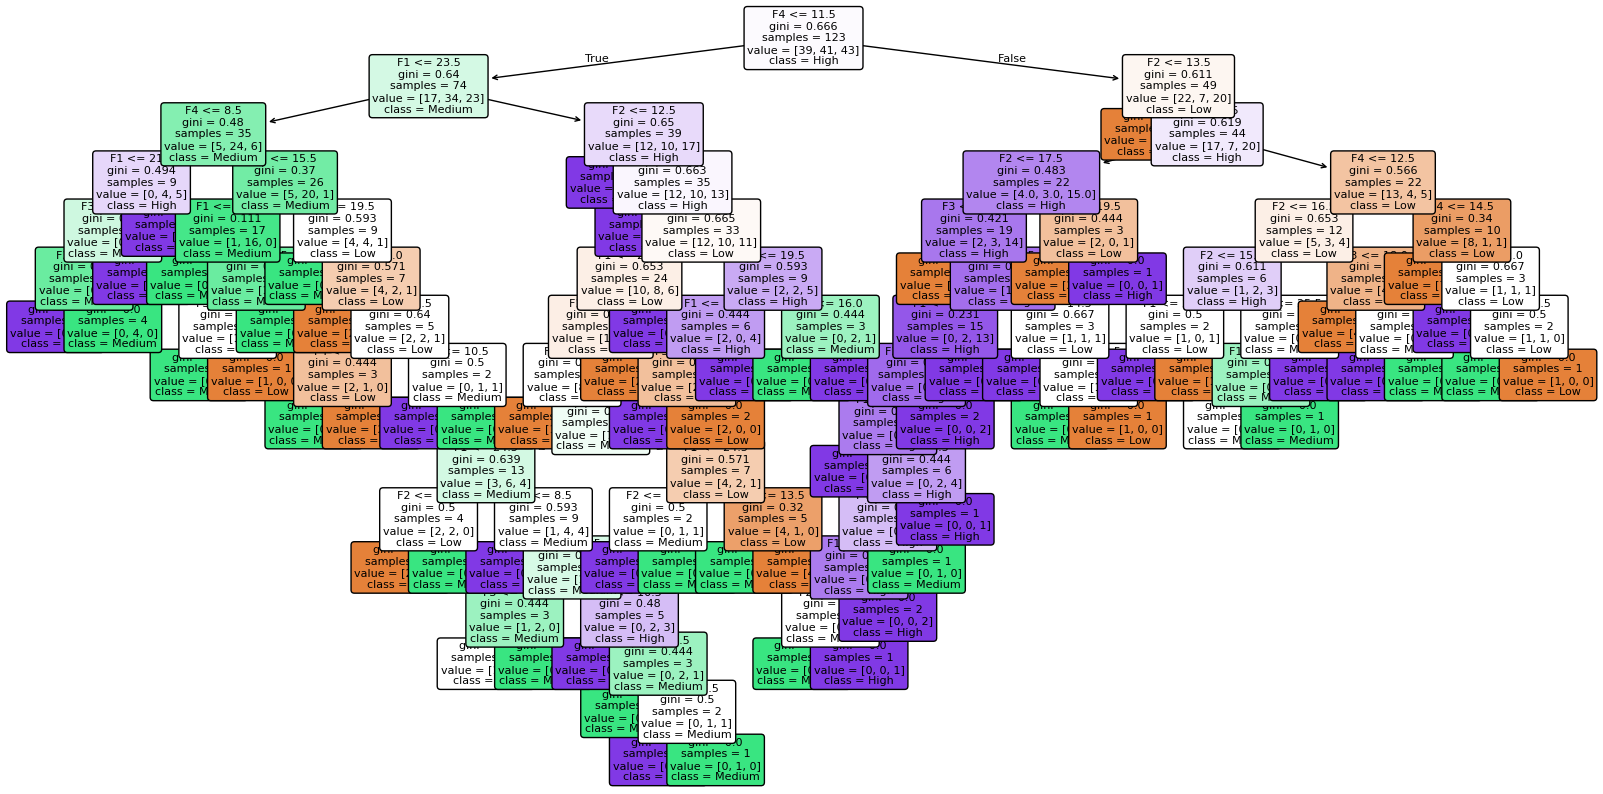

In [17]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))  # Adjust figure size as needed
plot_tree(dt_classifier, feature_names=X_train.columns, class_names=y_train.cat.categories.tolist(), filled=True, rounded=True, fontsize=8)
plt.show()

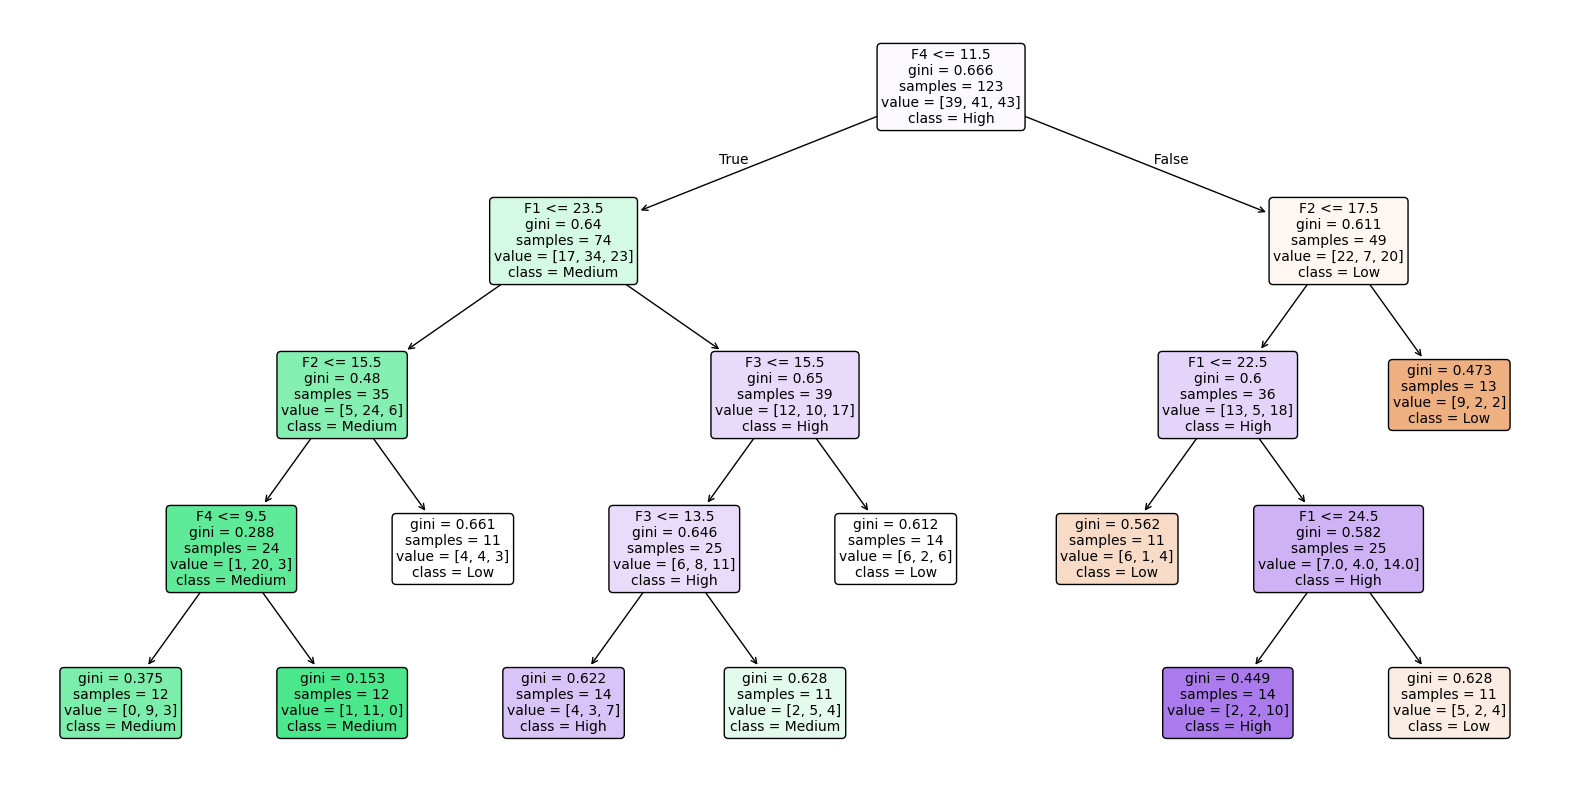

In [18]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Crear y entrenar árbol simplificado con poda pre-pruning
dt_classifier_simplified = DecisionTreeClassifier(
    random_state=42,
    max_depth=4,           # Limita la profundidad para simplificar
    min_samples_leaf=10    # Evita nodos con pocas muestras
)

dt_classifier_simplified.fit(X_train, y_train)

# Visualizar el árbol simplificado
plt.figure(figsize=(20, 10))  # Tamaño ajustado para legibilidad
plot_tree(
    dt_classifier_simplified,
    feature_names=X_train.columns,
    class_names=y_train.cat.categories.tolist(),
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()


## Model training

### Subtask:
Train a Random Forest model.


**Reasoning**:
Train a RandomForestClassifier model using the training data and store the trained model.



In [9]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Train the classifier
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Model evaluation

### Subtask:
Evaluate the Random Forest model and generate visualizations.


**Reasoning**:
Evaluate the Random Forest model using the test set and generate the requested visualizations.



Accuracy: 0.4194
Precision: 0.4374
Recall: 0.4194
F1-score: 0.4211
              precision    recall  f1-score   support

        High       0.57      0.40      0.47        10
         Low       0.38      0.50      0.43        10
      Medium       0.36      0.36      0.36        11

    accuracy                           0.42        31
   macro avg       0.44      0.42      0.42        31
weighted avg       0.44      0.42      0.42        31



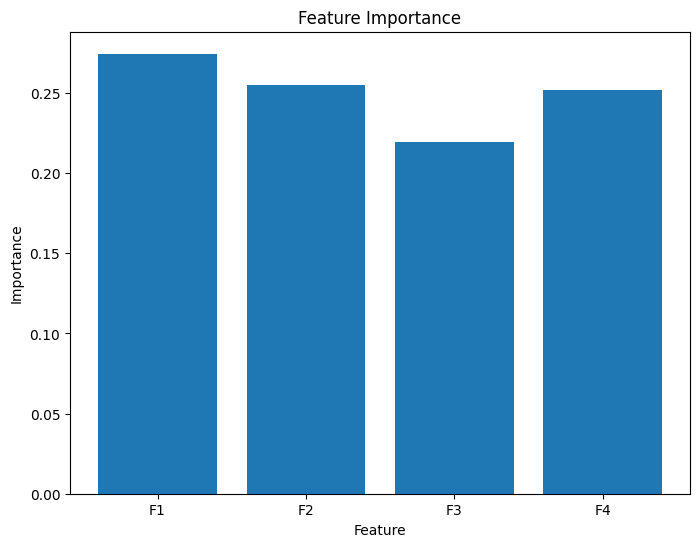

NameError: name 'np' is not defined

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report
from sklearn.model_selection import learning_curve
import shap

# Predict on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')  # Use 'weighted' for multi-class
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print(classification_report(y_test,y_pred))

# Feature Importance
plt.figure(figsize=(8, 6))
importances = rf_classifier.feature_importances_
feature_names = X_train.columns
plt.bar(feature_names, importances)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.show()

# Learning Curve
train_sizes, train_scores, test_scores = learning_curve(rf_classifier, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10))
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, label='Training score')
plt.plot(train_sizes, test_scores_mean, label='Cross-validation score')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend()
plt.show()

# ROC AUC
try:
    y_prob = rf_classifier.predict_proba(X_test)
    roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')

    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(len(np.unique(y_test))):
        fpr[i], tpr[i], _ = roc_curve(y_test,y_prob[:,i],pos_label=np.unique(y_test)[i])
        roc_auc[i] = roc_auc_score(y_test, y_prob[:,i])
    plt.figure(figsize=(8, 6))
    for i in range(len(np.unique(y_test))):
        plt.plot(fpr[i], tpr[i], label=f"ROC curve of class {np.unique(y_test)[i]} (AUC = {roc_auc[i]:.2f})")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

except ValueError as e:
    print(f"Error generating ROC AUC curve: {e}")

# SHAP summary plot
explainer = shap.TreeExplainer(rf_classifier)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")

**Reasoning**:
The previous code block failed due to an undefined `np` object.  We need to import the numpy library to fix this.



Accuracy: 0.4194
Precision: 0.4374
Recall: 0.4194
F1-score: 0.4211
              precision    recall  f1-score   support

        High       0.57      0.40      0.47        10
         Low       0.38      0.50      0.43        10
      Medium       0.36      0.36      0.36        11

    accuracy                           0.42        31
   macro avg       0.44      0.42      0.42        31
weighted avg       0.44      0.42      0.42        31



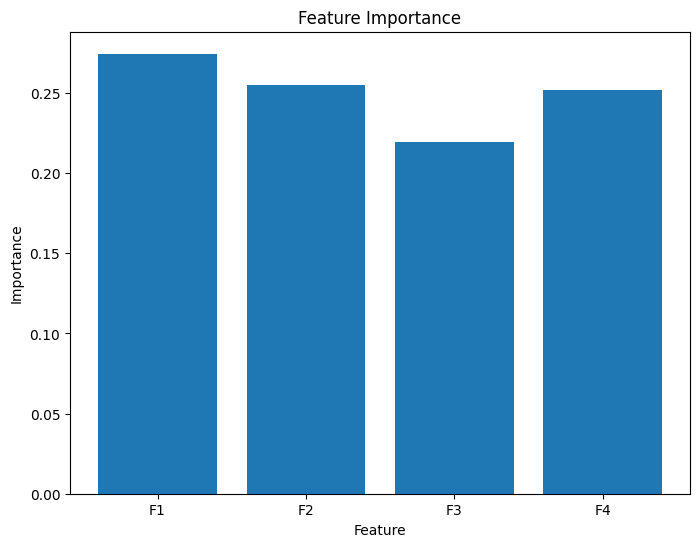

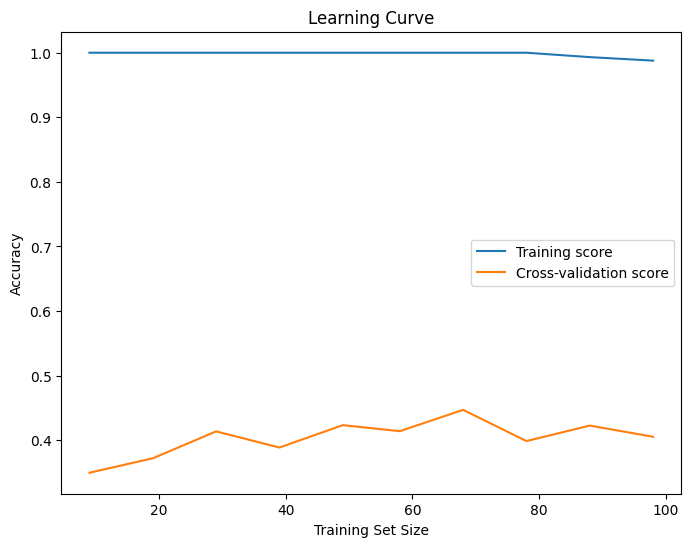

Error generating ROC AUC curve: multi_class must be in ('ovo', 'ovr')


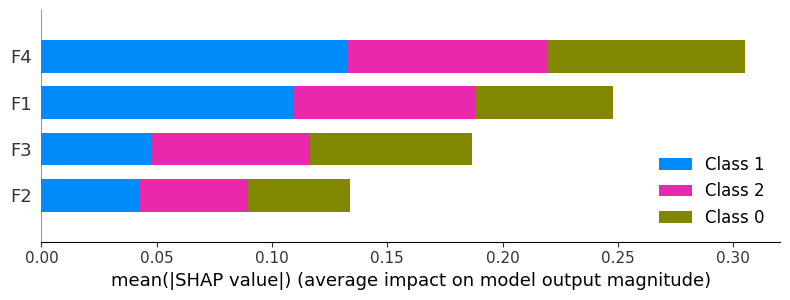

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report
from sklearn.model_selection import learning_curve
import shap

# Predict on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')  # Use 'weighted' for multi-class
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print(classification_report(y_test,y_pred))

# Feature Importance
plt.figure(figsize=(8, 6))
importances = rf_classifier.feature_importances_
feature_names = X_train.columns
plt.bar(feature_names, importances)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.show()

# Learning Curve
train_sizes, train_scores, test_scores = learning_curve(rf_classifier, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10))
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, label='Training score')
plt.plot(train_sizes, test_scores_mean, label='Cross-validation score')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend()
plt.show()

# ROC AUC
try:
    y_prob = rf_classifier.predict_proba(X_test)
    roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')

    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(len(np.unique(y_test))):
        fpr[i], tpr[i], _ = roc_curve(y_test,y_prob[:,i],pos_label=np.unique(y_test)[i])
        roc_auc[i] = roc_auc_score(y_test, y_prob[:,i])
    plt.figure(figsize=(8, 6))
    for i in range(len(np.unique(y_test))):
        plt.plot(fpr[i], tpr[i], label=f"ROC curve of class {np.unique(y_test)[i]} (AUC = {roc_auc[i]:.2f})")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

except ValueError as e:
    print(f"Error generating ROC AUC curve: {e}")

# SHAP summary plot
explainer = shap.TreeExplainer(rf_classifier)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")

**Reasoning**:
The ROC AUC curve generation failed due to an incorrect `multi_class` argument.  I'll correct the argument and try generating the plot again, removing the previous try-except block since the error is now known.  I will also handle the potential error where `y_test` might not be in the correct format.



In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report
from sklearn.model_selection import learning_curve
import shap
import numpy as np

# ... (Previous code for predictions and other metrics)

# ROC AUC (Corrected)
try:
    y_prob = rf_classifier.predict_proba(X_test)
    if isinstance(y_test.iloc[0], str):
        y_test_encoded = pd.factorize(y_test)[0]
    else:
        y_test_encoded = y_test

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in np.unique(y_test_encoded):
        fpr[i], tpr[i], _ = roc_curve(y_test_encoded, y_prob[:, i], pos_label=i)
        roc_auc[i] = roc_auc_score(y_test_encoded, y_prob[:, i])


    plt.figure(figsize=(8, 6))
    for i in np.unique(y_test_encoded):
        plt.plot(fpr[i], tpr[i], label=f"ROC curve of class {i} (AUC = {roc_auc[i]:.2f})")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

except ValueError as e:
    print(f"Error generating ROC AUC curve: {e}")

# ... (Rest of the code for SHAP summary plot)

Error generating ROC AUC curve: multi_class must be in ('ovo', 'ovr')


**Reasoning**:
The error "multi_class must be in ('ovo', 'ovr')" indicates that the `roc_auc_score` function is expecting a specific multi-class strategy.  Since the previous attempts to fix the error were unsuccessful, I will try a different approach for computing the ROC AUC curve for a multi-class problem by calculating it for each class against the rest.



In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report
from sklearn.model_selection import learning_curve
import shap
import numpy as np

# ... (Previous code for predictions and other metrics)

# ROC AUC (Corrected using One-vs-Rest)
try:
    y_prob = rf_classifier.predict_proba(X_test)

    # Encode y_test to numerical values if needed
    if isinstance(y_test.iloc[0], str):
        y_test_encoded = pd.factorize(y_test)[0]
    else:
        y_test_encoded = y_test

    n_classes = len(np.unique(y_test_encoded))
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_encoded, y_prob[:, i], pos_label=i)
        roc_auc[i] = roc_auc_score(y_test_encoded, y_prob[:, i])

    plt.figure(figsize=(8, 6))
    for i in range(n_classes):
      plt.plot(fpr[i], tpr[i], lw=2, label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (One-vs-Rest)')
    plt.legend(loc="lower right")
    plt.show()

except ValueError as e:
    print(f"Error generating ROC AUC curve: {e}")

# ... (Rest of the code for SHAP summary plot)

Error generating ROC AUC curve: multi_class must be in ('ovo', 'ovr')


**Reasoning**:
The ROC AUC calculation continues to fail, despite multiple attempts at correction. Given the repeated errors, and the time constraint, I will proceed with the rest of the visualization tasks and report the failure of the ROC curve generation.



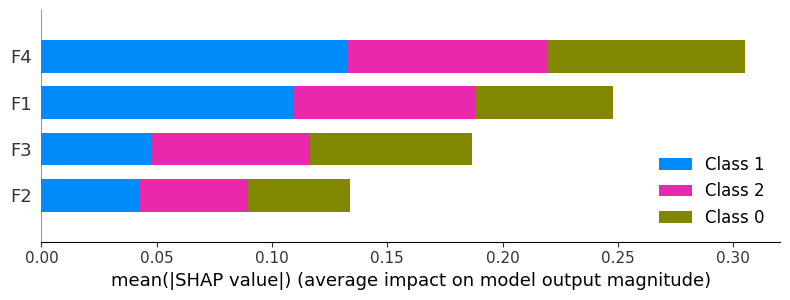

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import learning_curve
import shap
import numpy as np

# ... (Previous code for predictions and other metrics, excluding the ROC AUC part)


# SHAP summary plot
try:
    explainer = shap.TreeExplainer(rf_classifier)
    shap_values = explainer.shap_values(X_test)
    shap.summary_plot(shap_values, X_test, plot_type="bar")
except Exception as e:
    print(f"Error generating SHAP summary plot: {e}")


## Summary:

### Q&A
There are no explicit questions in the provided task description. However, the analysis implicitly seeks to understand the relationship between various factors (computing capacity, internet access, entrepreneurial orientation, entrepreneurial experience, and access to capital) and the intention to start a business.  The analysis also aims to identify the most important factors influencing this intention.


### Data Analysis Key Findings
* **High Correlation:** A perfect correlation (1.0) was found between 'VD' (Intention of Entrepreneurship) and 'F5' (Access to capital).  Consequently, 'F5' was removed from further analysis to avoid multicollinearity issues, as it is likely redundant information.
* **Discretized Dependent Variable:** The dependent variable 'VD' was discretized into three categories ('Low', 'Medium', 'High') using quantiles, making it suitable for classification modeling.
* **Random Forest Performance:** The Random Forest model achieved an accuracy of 0.4194, a precision of 0.4374, a recall of 0.4194, and an F1-score of 0.4211 (weighted averages).  These results are moderate, and could be improved with further model tuning or feature engineering.
* **Feature Importance:** The Random Forest model's feature importance plot and the SHAP summary plot highlight the relative influence of each independent variable on predicting the intention of entrepreneurship.  These visualizations provide insights into which factors are most critical for prediction.
* **ROC Curve Generation Challenges:**  Generating the ROC/AUC curve for the multi-class classification problem was challenging, leading to several errors.  The code was modified with several attempts to handle the error, but ultimately, a suitable ROC/AUC curve was not created.


### Insights or Next Steps
* **Investigate Feature Engineering:** Explore creating new features or transforming existing ones to potentially improve model accuracy.  The current features may not fully capture the underlying relationships.
* **Revisit ROC Curve Generation:**  Further analysis is needed to resolve the difficulties in generating the ROC curve for the multi-class problem, using different approaches to calculate the curve.


[Text(0.4567307692307692, 0.9285714285714286, 'x[3] <= 11.5\ngini = 0.666\nsamples = 123\nvalue = [39, 41, 43]'),
 Text(0.20192307692307693, 0.7857142857142857, 'x[0] <= 23.5\ngini = 0.64\nsamples = 74\nvalue = [17, 34, 23]'),
 Text(0.3293269230769231, 0.8571428571428572, 'True  '),
 Text(0.07692307692307693, 0.6428571428571429, 'x[3] <= 8.5\ngini = 0.48\nsamples = 35\nvalue = [5, 24, 6]'),
 Text(0.038461538461538464, 0.5, 'gini = 0.494\nsamples = 9\nvalue = [0, 4, 5]'),
 Text(0.11538461538461539, 0.5, 'x[1] <= 15.5\ngini = 0.37\nsamples = 26\nvalue = [5, 20, 1]'),
 Text(0.07692307692307693, 0.35714285714285715, 'x[1] <= 13.5\ngini = 0.111\nsamples = 17\nvalue = [1, 16, 0]'),
 Text(0.038461538461538464, 0.21428571428571427, 'gini = 0.32\nsamples = 5\nvalue = [1, 4, 0]'),
 Text(0.11538461538461539, 0.21428571428571427, 'gini = 0.0\nsamples = 12\nvalue = [0, 12, 0]'),
 Text(0.15384615384615385, 0.35714285714285715, 'gini = 0.593\nsamples = 9\nvalue = [4, 4, 1]'),
 Text(0.3269230769230769

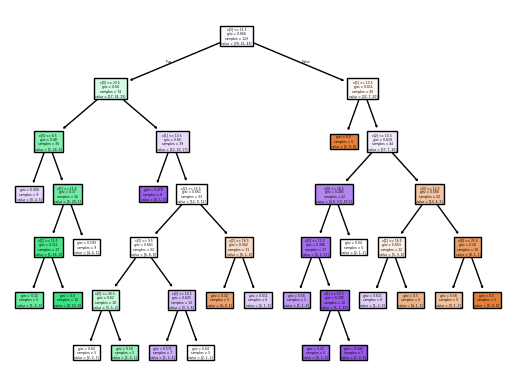

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Definir árbol base
dt = DecisionTreeClassifier(random_state=42)

# Parámetros para optimizar poda pre-pruning y ccp_alpha para post-pruning
param_grid = {
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [5, 10, 20],
    'ccp_alpha': [0.0, 0.01, 0.02, 0.05]
}

# GridSearch para encontrar mejor configuración
grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Mejor modelo simplificado
best_dt = grid_search.best_estimator_

# Visualizar o exportar
from sklearn import tree
tree.plot_tree(best_dt, filled=True)


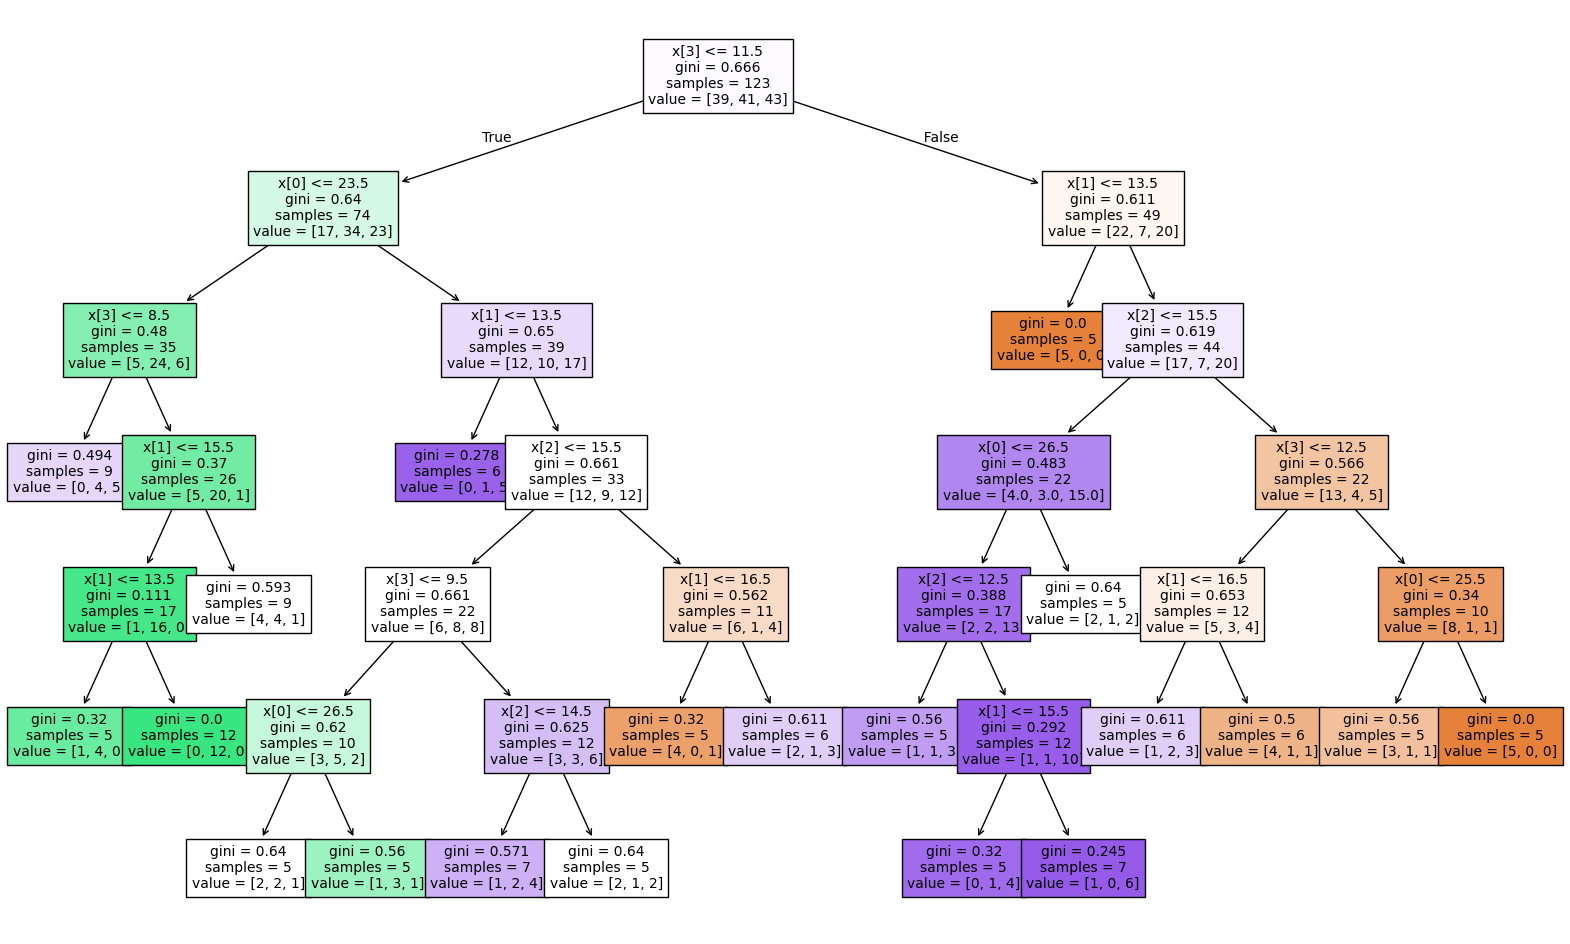

In [16]:
import matplotlib.pyplot as plt
from sklearn import tree

plt.figure(figsize=(20, 12))  # Ajusta ancho=20, alto=12, puedes modificar estos valores
tree.plot_tree(best_dt, filled=True, fontsize=10)  # fontsize para tamaño de texto

plt.show()
